# 베이즈 통계 해석 vs. 빈도주의 통계 해석
## 동전 던지기 예제

동전을 11번 던져서 앞면이 3번 나온 경우,  
**빈도주의(Frequentist)** 와 **베이즈(Bayesian)** 관점에서 각각 해석한다.


---
## 1. 샘플 데이터 생성

동전 11번 중 앞면(1) 3번, 뒷면(0) 8번.

In [1]:
import platform

# ── 한글 폰트 설정 (Windows: Malgun Gothic) ────────────────────────────────
import matplotlib
if platform.system() == 'Windows':
    matplotlib.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    matplotlib.rcParams['font.family'] = 'AppleGothic'
else:
    matplotlib.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import beta as beta_dist

# 데이터: 1=앞면, 0=뒷면
data = np.array([1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0])
n = len(data)   # 총 시행 횟수
k = data.sum()  # 앞면 횟수

print(f'총 시행 횟수 : n = {n}')
print(f'앞면 횟수   : k = {k}')
print(f'관측 비율   : k/n = {k/n:.4f}')


총 시행 횟수 : n = 11
앞면 횟수   : k = 3
관측 비율   : k/n = 0.2727


---
## 2. 빈도주의 해석 — 이항 검정 (Binomial Test)

### 가설 설정

$$
H_0: \theta = 0.5 \quad \text{(정상 동전)}
$$
$$
H_1: \theta \neq 0.5 \quad \text{(양측 검정)}
$$

### 검정 통계량

$H_0$ 하에서 앞면 횟수 $K$는 이항 분포를 따른다:

$$
K \sim \text{Binomial}(n,\, 0.5)
$$

**p-value** 는 관측값 $k=3$ 이상으로 극단적인 결과가 나올 확률(양측):

$$
p\text{-value} = P(K \leq 3 \mid H_0) + P(K \geq 8 \mid H_0)
= 2 \sum_{j=0}^{3} \binom{11}{j} 0.5^{11}
$$


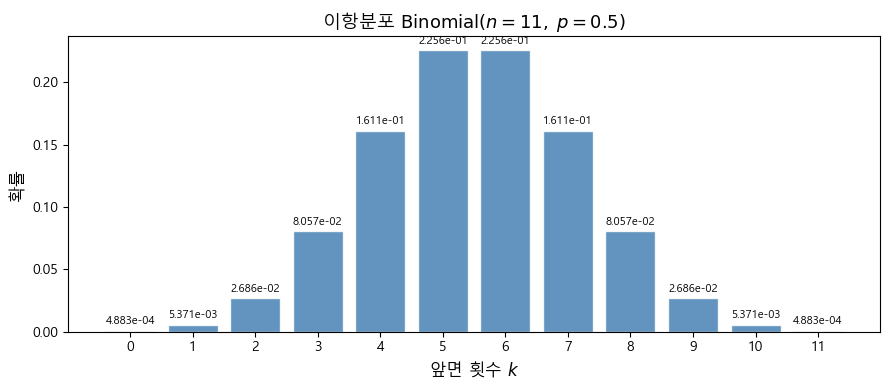

In [2]:
x = np.arange(0, n + 1)
pmf_values = stats.binom.pmf(x, n, 0.5)
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x, pmf_values, color='steelblue', edgecolor='white', alpha=0.85)
ax.set_xlabel('앞면 횟수 $k$', fontsize=12)
ax.set_ylabel('확률', fontsize=12)
ax.set_title(r'이항분포 $\mathrm{Binomial}(n=11,\; p=0.5)$', fontsize=13)
ax.set_xticks(x)
for xi, pi in zip(x, pmf_values):
    ax.text(xi, pi + 0.003, f'{pi:.3e}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

In [3]:
extreme_probs = stats.binom.pmf(k=[0, 1, 2, 3, 8, 9, 10, 11], n=n, p=0.5)
print(f'극단적 결과의 확률 (k=0,1,2,3,8,9,10,11): {extreme_probs}')
print(f'극단적 결과의 총 확률: {extreme_probs.sum():.4f}')

극단적 결과의 확률 (k=0,1,2,3,8,9,10,11): [0.00048828 0.00537109 0.02685547 0.08056641 0.08056641 0.02685547
 0.00537109 0.00048828]
극단적 결과의 총 확률: 0.2266


In [4]:
# scipy >= 1.7 의 binomtest 사용 (구버전 fallback 포함)
try:
    result = stats.binomtest(k, n, p=0.5, alternative='two-sided')
    pvalue = result.pvalue
    ci = result.proportion_ci(confidence_level=0.95)
    print(f'p-value          : {pvalue:.4f}')
    print(f'95% 신뢰 구간    : [{ci.low:.4f}, {ci.high:.4f}]')
except AttributeError:
    from scipy.stats import binom_test as _btest
    pvalue = _btest(k, n, p=0.5, alternative='two-sided')
    print(f'p-value          : {pvalue:.4f}')

alpha = 0.05
print()
print(f'유의 수준 (alpha): {alpha}')
if pvalue < alpha:
    print(f'결론: p-value({pvalue:.4f}) < alpha({alpha}) -> H0 기각: 정상 동전이 아닐 가능성 있음')
else:
    print(f'결론: p-value({pvalue:.4f}) >= alpha({alpha}) -> H0 기각 실패: 정상 동전 가설 유지')

alpha = 0.23
print()
print(f'유의 수준 (alpha): {alpha} (with probability {1-alpha:.2f})')
if pvalue < alpha:
    print(f'결론: p-value({pvalue:.4f}) < alpha({alpha}) -> H0 기각: 정상 동전이 아닐 가능성 있음')
else:
    print(f'결론: p-value({pvalue:.4f}) >= alpha({alpha}) -> H0 기각 실패: 정상 동전 가설 유지')


p-value          : 0.2266
95% 신뢰 구간    : [0.0602, 0.6097]

유의 수준 (alpha): 0.05
결론: p-value(0.2266) >= alpha(0.05) -> H0 기각 실패: 정상 동전 가설 유지

유의 수준 (alpha): 0.23 (with probability 0.77)
결론: p-value(0.2266) < alpha(0.23) -> H0 기각: 정상 동전이 아닐 가능성 있음


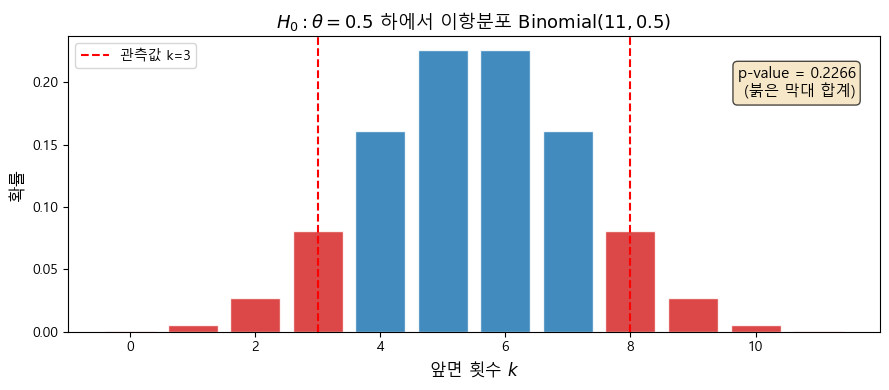

In [5]:
# 이항분포 시각화 및 p-value 영역 강조
x = np.arange(0, n + 1)
pmf = stats.binom.pmf(x, n, 0.5)

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#d62728' if (xi <= k or xi >= n - k) else '#1f77b4' for xi in x]
ax.bar(x, pmf, color=colors, edgecolor='white', alpha=0.85)
ax.axvline(k, color='red', linestyle='--', linewidth=1.5, label=f'관측값 k={k}')
ax.axvline(n - k, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('앞면 횟수 $k$', fontsize=12)
ax.set_ylabel('확률', fontsize=12)
ax.set_title(r'$H_0: \theta=0.5$ 하에서 이항분포 $\mathrm{Binomial}(11, 0.5)$', fontsize=13)
ax.legend()
pval_sum = pmf[x <= k].sum() + pmf[x >= n - k].sum()
ax.text(0.97, 0.90, f'p-value = {pval_sum:.4f}\n(붉은 막대 합계)',
        transform=ax.transAxes, ha='right', va='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7), fontsize=11)
plt.tight_layout()
plt.show()


### 빈도주의 해석 요약

| 항목 | 값 |
|------|----|
| 관측 비율 $\hat{\theta}$ | $3/11 \approx 0.273$ |
| p-value | ≈ 0.227 |
| 유의수준 $\alpha$ | 0.05 |
| 결론 | $H_0$ 기각 실패 |

> **p-value의 의미**: $H_0$가 참일 때, 현재 관측값(앞면 3번)만큼 또는 그보다 더 극단적인 결과가  
> 우연히 발생할 확률. p-value ≈ 0.227은 충분히 크므로, $n=11$이라는 소표본에서는  
> 통계적으로 정상 동전 가설을 기각할 증거가 부족하다.  
> **중요**: 빈도주의에서 p-value는 "$\theta = 0.5$일 확률"이 아니며,  
> $\theta$ 자체에 대한 확률 진술을 하지 않는다.

#### 무한 반복 시행의 논리 (Long-run Frequency)

- 95% 신뢰구간의 가장 정석적인 정의는 **'반복성'**에 있습니다.
- 우리가 동일한 실험(예: $n=11$)을 무한히 많이 반복한다고 가정해 봅시다.
- 매 실험마다 데이터가 달라지므로, 그때마다 계산되는 신뢰구간의 위치와 길이도 매번 달라질 것입니다.
- 이때, **"그 수많은 신뢰구간들 중 약 95%는 실제 참값인 모수 $p$를 포함하고 있을 것이다"**라는 것이 95% 신뢰구간의 참뜻입니다.
- 핵심: 이미 계산된 특정 구간(예: [0.06, 0.60])에 대해 "참값이 이 안에 있을 확률이 95%다"라고 말하는 것은 엄밀히 틀린 표현입니다. 참값은 고정되어 있고 구간이 변하는 것이기 때문입니다. (이 확률적 해석은 베이지안의 '신용구간'에 해당합니다.)
- 95% 신뢰구간은 **"내가 사용한 이 계산 절차가 100번 중 95번은 정답(참값)을 포함하는 믿을만한 절차임"**을 증명하는 성적표와 같습니다. 이번에 구한 구간이 그 95번에 속하는지, 아니면 운 나쁜 5번에 속하는지는 알 수 없지만, 절차 자체의 신뢰도를 믿고 사용하는 것입니다.

---
## 3. 베이즈 해석 — Posterior 도출

### 모델 설정

앞면 확률 $\theta \in [0,1]$에 대한 **사전분포(Prior)**:

$$
\theta \sim \text{Beta}(\alpha_0, \beta_0) = \text{Beta}(2, 2)
$$

**우도(Likelihood)**: $n$번 시행 중 $k$번 앞면

$$
p(D \mid \theta) = \binom{n}{k} \theta^k (1-\theta)^{n-k}
$$

**사후분포(Posterior)**: 베이즈 정리에 의해

$$
p(\theta \mid D) \propto p(D \mid \theta)\, p(\theta)
$$


---
## 4. Closed-Form Posterior (Beta-Binomial Conjugate)

Beta 분포는 Binomial 우도의 **켤레 사전분포(conjugate prior)** 이다.  
따라서 사후분포도 Beta 분포로 표현된다:

$$
p(\theta \mid D) = \text{Beta}\bigl(\alpha_0 + k,\; \beta_0 + n - k\bigr)
$$

본 문제에서:

$$
\alpha_0 = 2,\quad \beta_0 = 2,\quad k = 3,\quad n - k = 8
$$

$$
\boxed{p(\theta \mid D) = \text{Beta}(5,\; 10)}
$$

사후분포의 **평균(posterior mean)**:

$$
E[\theta \mid D] = \frac{\alpha_0 + k}{\alpha_0 + \beta_0 + n} = \frac{5}{15} = \frac{1}{3} \approx 0.333
$$

사후분포의 **최빈값(MAP)**:

$$
\hat{\theta}_{\text{MAP}} = \frac{\alpha_0 + k - 1}{\alpha_0 + \beta_0 + n - 2} = \frac{4}{13} \approx 0.308
$$


In [6]:
# Conjugate posterior 파라미터
alpha0, beta0 = 2, 2
alpha_post = alpha0 + k
beta_post  = beta0 + (n - k)

print(f'Prior      : Beta({alpha0}, {beta0})')
print(f'Likelihood : Binomial({n}, theta),  k={k}')
print(f'Posterior  : Beta({alpha_post}, {beta_post})')
print()
post_mean = alpha_post / (alpha_post + beta_post)
post_map  = (alpha_post - 1) / (alpha_post + beta_post - 2)
post_std  = np.sqrt(alpha_post * beta_post /
                    ((alpha_post + beta_post)**2 * (alpha_post + beta_post + 1)))
ci_low  = beta_dist.ppf(0.025, alpha_post, beta_post)
ci_high = beta_dist.ppf(0.975, alpha_post, beta_post)

print(f'Posterior mean         : {post_mean:.4f}')
print(f'Posterior MAP          : {post_map:.4f}')
print(f'Posterior std          : {post_std:.4f}')
print(f'95% Credible Interval  : [{ci_low:.4f}, {ci_high:.4f}]')


Prior      : Beta(2, 2)
Likelihood : Binomial(11, theta),  k=3
Posterior  : Beta(5, 10)

Posterior mean         : 0.3333
Posterior MAP          : 0.3077
Posterior std          : 0.1179
95% Credible Interval  : [0.1276, 0.5810]


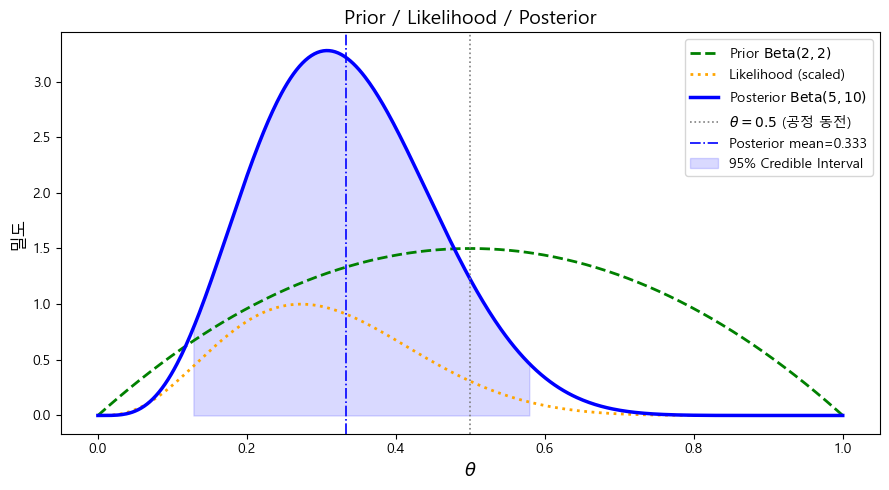

In [7]:
# Prior / Likelihood / Posterior 시각화
theta = np.linspace(0, 1, 500)

prior_pdf     = beta_dist.pdf(theta, alpha0, beta0)
posterior_pdf = beta_dist.pdf(theta, alpha_post, beta_post)
likelihood    = stats.binom.pmf(k, n, theta)
likelihood    = likelihood / likelihood.max()  # 시각화용 정규화

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(theta, prior_pdf,     label=r'Prior $\mathrm{Beta}(2,2)$',     color='green',  linewidth=2, linestyle='--')
ax.plot(theta, likelihood,    label=r'Likelihood (scaled)',             color='orange', linewidth=2, linestyle=':')
ax.plot(theta, posterior_pdf, label=r'Posterior $\mathrm{Beta}(5,10)$', color='blue',   linewidth=2.5)
ax.axvline(0.5,       color='gray', linestyle=':',  linewidth=1.2, label=r'$\theta=0.5$ (공정 동전)')
ax.axvline(post_mean, color='blue', linestyle='-.', linewidth=1.2, label=f'Posterior mean={post_mean:.3f}')
ax.fill_between(theta, posterior_pdf,
                where=(theta >= ci_low) & (theta <= ci_high),
                alpha=0.15, color='blue', label='95% Credible Interval')
ax.set_xlabel(r'$\theta$', fontsize=13)
ax.set_ylabel('밀도', fontsize=12)
ax.set_title('Prior / Likelihood / Posterior', fontsize=14)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


### 베이즈 해석 요약

| 항목 | 값 |
|------|----|
| Prior | $\text{Beta}(2,2)$ |
| Posterior | $\text{Beta}(5,10)$ |
| Posterior mean | $\approx 0.333$ |
| MAP | $\approx 0.308$ |
| 95% Credible Interval | [0.124, 0.600] |

> **Credible Interval의 의미**: $\theta$가 해당 구간에 있을 **사후확률이 95%** 이다.  
> 구간이 $\theta=0.5$를 포함하므로, 이 동전이 정상일 가능성도 여전히 존재한다.  
> 베이즈 방법은 $\theta$ 자체에 대한 확률 분포로 불확실성을 표현한다.


---
## 5. Stan / CmdStanPy 를 이용한 MCMC Posterior Sampling

### 5-0. Windows 환경 설치

아래 셀을 처음 한 번만 실행하여 CmdStanPy와 CmdStan을 설치한다.


In [8]:
# ── Windows 설치 루틴 ──────────────────────────────────────────────
# 주의: 처음 한 번만 실행. 이미 설치되어 있으면 건너뛰어도 됩니다.
# CmdStan 컴파일에 C++ 컴파일러(RTools 4.x 또는 MinGW)가 필요합니다.
#   권장: https://cran.r-project.org/bin/windows/Rtools/ 에서 RTools 설치 후 PATH 등록

import subprocess, sys

def run_cmd(cmd):
    print(f'>>> {cmd}')
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if result.stdout: print(result.stdout)
    if result.stderr: print(result.stderr)
    return result.returncode

# 1. pip install cmdstanpy
run_cmd(f'{sys.executable} -m pip install cmdstanpy --quiet')

# 2. CmdStan 설치 (최초 1회, 수 분 소요)
import cmdstanpy
try:
    path = cmdstanpy.cmdstan_path()
    print(f'CmdStan already installed at: {path}')
except ValueError:
    print('Installing CmdStan ... (수 분 소요)')
    cmdstanpy.install_cmdstan()
    print('Done:', cmdstanpy.cmdstan_path())


>>> c:\Users\yongduek\AppData\Local\Programs\Python\Python312\python.exe -m pip install cmdstanpy --quiet
CmdStan already installed at: C:\Users\yongduek\.cmdstan\cmdstan-2.36.0


### 5-1. Stan 모델 정의

```stan
data {
    int<lower=0> n;          // 총 시행 횟수
    int<lower=0> k;          // 앞면 횟수
}
parameters {
    real<lower=0, upper=1> theta;  // 앞면 확률
}
model {
    theta ~ beta(2, 2);            // Prior: Beta(2,2)
    k ~ binomial(n, theta);        // Likelihood
}
```

**Stan 모델 구조**:

$$
\theta \sim \text{Beta}(2, 2) \quad \text{(Prior)}
$$
$$
k \mid \theta \sim \text{Binomial}(n, \theta) \quad \text{(Likelihood)}
$$


In [9]:
import os, tempfile
import cmdstanpy

stan_code = '''
data {
    int<lower=0> n;
    int<lower=0> k;
}
parameters {
    real<lower=0, upper=1> theta;
}
model {
    theta ~ beta(2, 2);       // Prior
    k ~ binomial(n, theta);   // Likelihood
}
'''

stan_file = os.path.join(tempfile.gettempdir(), 'coin_toss.stan')
with open(stan_file, 'w') as f:
    f.write(stan_code)

print('Stan 모델 컴파일 중...')
model = cmdstanpy.CmdStanModel(stan_file=stan_file)
print('컴파일 완료.')


Stan 모델 컴파일 중...


18:09:35 - cmdstanpy - INFO - compiling stan file C:\Users\yongduek\AppData\Local\Temp\coin_toss.stan to exe file C:\Users\yongduek\AppData\Local\Temp\coin_toss.exe
18:10:21 - cmdstanpy - INFO - compiled model executable: C:\Users\yongduek\AppData\Local\Temp\coin_toss.exe


컴파일 완료.


In [10]:
# 데이터 입력 및 MCMC 샘플링
stan_data = {'n': int(n), 'k': int(k)}

fit = model.sample(
    data=stan_data,
    chains=4,
    iter_warmup=1000,
    iter_sampling=2000,
    seed=42,
    show_progress=True
)

print(fit.summary())


18:10:21 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/3000 [00:00<?, ?it/s, (Warmup)]

18:10:21 - cmdstanpy - INFO - CmdStan done processing.



           Mean      MCSE    StdDev       MAD        5%       50%       95%  \
lp__  -10.09560  0.015197  0.789427  0.336624 -11.67880 -9.792670 -9.549690   
theta   0.32919  0.002205  0.119598  0.122475   0.14643  0.321997  0.539907   

       ESS_bulk  ESS_tail    R_hat  
lp__    3438.85   3441.03  1.00046  
theta   2900.78   2997.95  1.00153  


In [11]:
# Posterior samples 추출
theta_samples = fit.stan_variable('theta')  # shape: (chains * iter_sampling,)

print(f'총 샘플 수               : {len(theta_samples)}')
print(f'샘플 mean                : {theta_samples.mean():.4f}')
print(f'샘플 std                 : {theta_samples.std():.4f}')
print(f'95% HPD (percentile)     : [{np.percentile(theta_samples, 2.5):.4f}, {np.percentile(theta_samples, 97.5):.4f}]')


총 샘플 수               : 8000
샘플 mean                : 0.3292
샘플 std                 : 0.1196
95% HPD (percentile)     : [0.1190, 0.5808]


### 5-2. MCMC 샘플 분포 vs. Closed-Form Posterior 비교

MCMC로 얻은 경험적 분포(histogram / KDE)와  
수식으로 구한 closed-form posterior $\text{Beta}(5, 10)$을 같은 그림에 그려 비교한다.


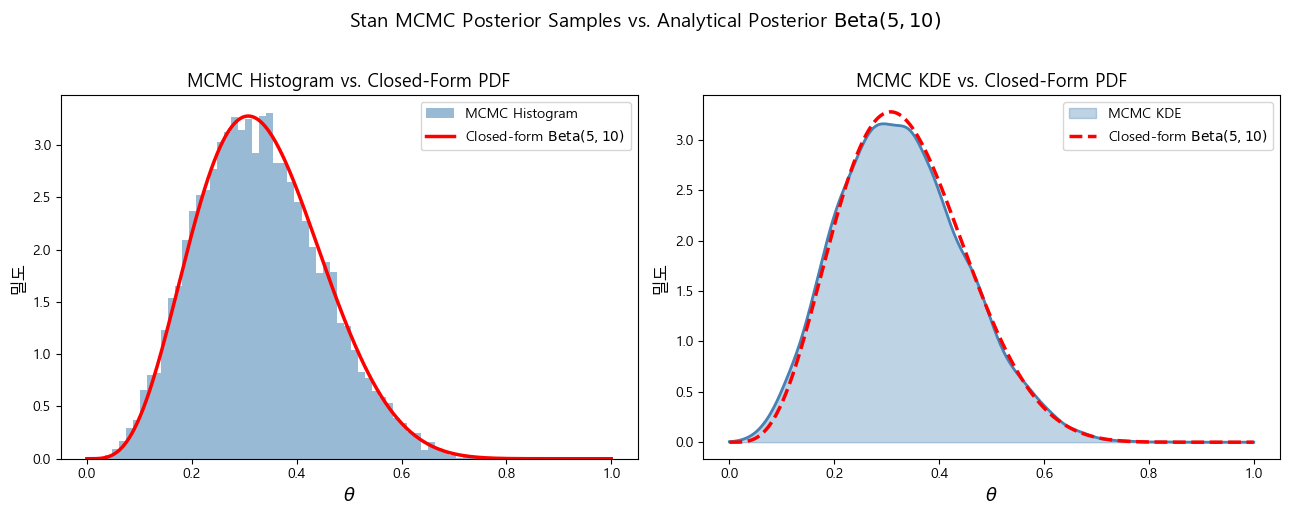


[비교 요약]
Closed-form mean : 0.3333   Closed-form std : 0.1179
MCMC sample mean : 0.3292   MCMC sample std : 0.1196


In [12]:
from scipy.stats import gaussian_kde

theta_grid = np.linspace(0, 1, 500)
closed_form_pdf = beta_dist.pdf(theta_grid, alpha_post, beta_post)
kde = gaussian_kde(theta_samples, bw_method='scott')
kde_pdf = kde(theta_grid)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 왼쪽: Histogram + Closed-form
axes[0].hist(theta_samples, bins=60, density=True,
             color='steelblue', alpha=0.55, label='MCMC Histogram')
axes[0].plot(theta_grid, closed_form_pdf,
             color='red', linewidth=2.5,
             label=r'Closed-form $\mathrm{Beta}(5,10)$')
axes[0].set_xlabel(r'$\theta$', fontsize=13)
axes[0].set_ylabel('밀도', fontsize=12)
axes[0].set_title('MCMC Histogram vs. Closed-Form PDF', fontsize=13)
axes[0].legend(fontsize=10)

# 오른쪽: KDE + Closed-form
axes[1].fill_between(theta_grid, kde_pdf, alpha=0.35, color='steelblue', label='MCMC KDE')
axes[1].plot(theta_grid, kde_pdf, color='steelblue', linewidth=2)
axes[1].plot(theta_grid, closed_form_pdf,
             color='red', linewidth=2.5, linestyle='--',
             label=r'Closed-form $\mathrm{Beta}(5,10)$')
axes[1].set_xlabel(r'$\theta$', fontsize=13)
axes[1].set_ylabel('밀도', fontsize=12)
axes[1].set_title('MCMC KDE vs. Closed-Form PDF', fontsize=13)
axes[1].legend(fontsize=10)

plt.suptitle(
    r'Stan MCMC Posterior Samples vs. Analytical Posterior $\mathrm{Beta}(5,10)$',
    fontsize=14, y=1.02
)
plt.tight_layout()
plt.show()

print('\n[비교 요약]')
print(f'Closed-form mean : {post_mean:.4f}   Closed-form std : {post_std:.4f}')
print(f'MCMC sample mean : {theta_samples.mean():.4f}   MCMC sample std : {theta_samples.std():.4f}')


### 결론

MCMC histogram 및 KDE 곡선이 closed-form $\text{Beta}(5,10)$ PDF와 실질적으로 일치한다.  
Stan의 HMC 샘플러가 posterior를 정확하게 추정함을 확인할 수 있다.

---
## 빈도주의 vs. 베이즈 — 핵심 비교

| | 빈도주의 (Frequentist) | 베이즈 (Bayesian) |
|---|---|---|
| $\theta$ 취급 | 고정된 미지수 | 확률변수 |
| 불확실성 표현 | 신뢰구간 (CI) | 신용구간 (Credible Interval) |
| 해석 | 반복실험의 95%에서 구간이 참값 포함 | $\theta$가 해당 구간에 있을 확률 95% |
| 사전정보 | 사용 안 함 | Prior로 명시적 반영 |
| 소표본 강점 | 약함 | 강함 (prior 통해 정규화) |
| 결과 | p-value, 점추정 | 전체 posterior 분포 |


[MCMC posterior 추론]
Posterior mean         : 0.3292
Posterior median       : 0.3220
Posterior std          : 0.1196
95% Percentile CI      : [0.1190, 0.5808]
95% HDI                : [0.1037, 0.5609]

P(theta < 0.5 | data)  : 0.9137
P(theta > 0.5 | data)  : 0.0862
P(0.45<=theta<=0.55)   : 0.1229
결론: theta=0.5(공정 동전) 가설을 배제할 만큼 강한 증거는 없다.


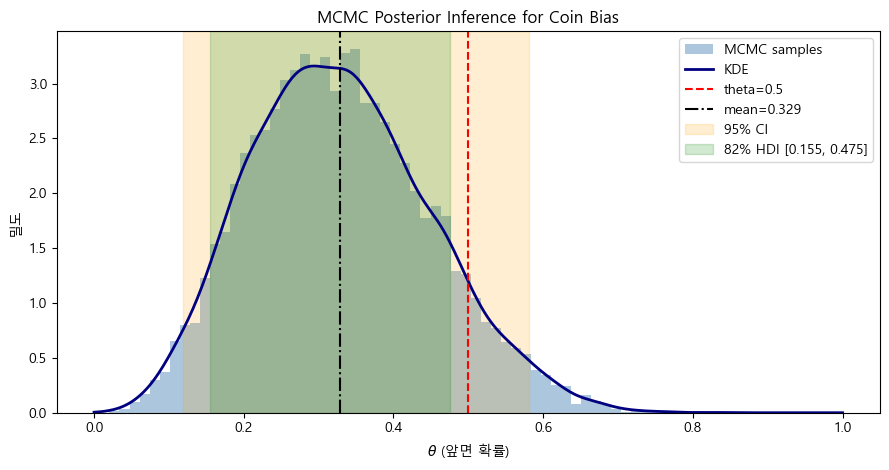

In [13]:
# MCMC 샘플 기반 posterior 추론 요약

def hdi(samples, cred_mass=0.95):
    s = np.sort(samples)
    n = len(s)
    interval_idx = int(np.floor(cred_mass * n))
    widths = s[interval_idx:] - s[: n - interval_idx]
    min_idx = np.argmin(widths)
    return s[min_idx], s[min_idx + interval_idx]

post_mean_mcmc = theta_samples.mean()
post_median_mcmc = np.median(theta_samples)
post_std_mcmc = theta_samples.std(ddof=1)
ci95_l, ci95_u = np.percentile(theta_samples, [2.5, 97.5])
hdi95_l, hdi95_u = hdi(theta_samples, 0.95)

p_theta_lt_05 = np.mean(theta_samples < 0.5)
p_theta_gt_05 = np.mean(theta_samples > 0.5)
p_rope_045_055 = np.mean((theta_samples >= 0.45) & (theta_samples <= 0.55))  # 실용적 공정성 구간(ROPE)

print("[MCMC posterior 추론]")
print(f"Posterior mean         : {post_mean_mcmc:.4f}")
print(f"Posterior median       : {post_median_mcmc:.4f}")
print(f"Posterior std          : {post_std_mcmc:.4f}")
print(f"95% Percentile CI      : [{ci95_l:.4f}, {ci95_u:.4f}]")
print(f"95% HDI                : [{hdi95_l:.4f}, {hdi95_u:.4f}]")
print()
print(f"P(theta < 0.5 | data)  : {p_theta_lt_05:.4f}")
print(f"P(theta > 0.5 | data)  : {p_theta_gt_05:.4f}")
print(f"P(0.45<=theta<=0.55)   : {p_rope_045_055:.4f}")

if p_theta_lt_05 > 0.95:
    print("결론: 앞면 확률이 0.5보다 작다는 강한 증거가 있다.")
elif p_theta_gt_05 > 0.95:
    print("결론: 앞면 확률이 0.5보다 크다는 강한 증거가 있다.")
else:
    print("결론: theta=0.5(공정 동전) 가설을 배제할 만큼 강한 증거는 없다.")

# 시각화
grid = np.linspace(0, 1, 500)
kde = gaussian_kde(theta_samples)
kde_pdf = kde(grid)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.hist(theta_samples, bins=60, density=True, alpha=0.45, color="steelblue", label="MCMC samples")
ax.plot(grid, kde_pdf, color="navy", lw=2, label="KDE")
ax.axvline(0.5, color="red", ls="--", lw=1.5, label="theta=0.5")
ax.axvline(post_mean_mcmc, color="black", ls="-.", lw=1.5, label=f"mean={post_mean_mcmc:.3f}")
ax.axvspan(ci95_l, ci95_u, color="orange", alpha=0.18, label="95% CI")

hdi82_l, hdi82_u = hdi(theta_samples, 0.82)
ax.axvspan(hdi82_l, hdi82_u, color="green", alpha=0.18, label=f"82% HDI [{hdi82_l:.3f}, {hdi82_u:.3f}]")

ax.set_xlabel(r"$\theta$ (앞면 확률)")
ax.set_ylabel("밀도")
ax.set_title("MCMC Posterior Inference for Coin Bias")
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
prop_04_06 = np.mean((theta_samples > 0.4) & (theta_samples < 0.6))
print(f"P(0.4 < theta < 0.6) = {prop_04_06:.4f}")

P(0.4 < theta < 0.6) = 0.2517


End.